[colab에서 실행하기](https://colab.research.google.com/github/science-odysseia/AILearning/blob/main/OpenCV기초.ipynb)

코랩에서 실행할 경우

아래 코드를 한 번 실행만 시켜 주시고 다음으로 넘어가 주세요.

In [1]:
import os, cv2, numpy as np, matplotlib.pyplot as plt
if "AILearning" not in os.getcwd():
    !git clone https://github.com/science-odysseia/AILearning.git
    os.chdir("/content/AILearning")
try:
    # 코랩 환경 시도
    from google.colab.patches import cv2_imshow
except ImportError:
    def cv2_imshow(img):
        import cv2
        plt.figure(figsize=(8, 6))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()

%matplotlib inline

# OpenCV 이미지 좌표체계
| numpy 배열 | opencv 이미지 |
| :---: | :---: |
| <img src="imgs/opencv/imgs/numpy1.png" width="300"> | <img src="imgs/opencv/imgs/OpenCV1.png" width="300"> |

특징 : 
- 원점위치 : 왼쪽 위
- x좌표 : 열
- y좌표 : 행

# 색상 표현 방식 : RGB, HSL, HSV

### 1. RGB

`R` : Red (빨강), `G` : Green (초록), `B` : Blue(파랑)

![RGB](imgs/opencv/imgs/RGB.png)

### 2. HSL vs HSV

`H` : Hue (색상)

`S` : Saturation (색의 선명도)

`L` : Lightness (밝기 : 100%가 흰색, 0%가 검정색, 50%가 가장 선명한 색)

`V` : Value (명도 : 빛의 세기, 100%가 가장 선명한 색)

|HSL|HSV|
|---|---|
|<img src="imgs/opencv/imgs/HSL.png" width="300">|<img src="imgs/opencv/imgs/HSV.jpg" width="300">|

# OpenCV 색상 시스템 : BGR

OpenCV의 기본 색상 시스템은 BGR, 역순으로 처리한다.

가령 입력된 색이 [255, 0, 0] 이라면

B, G, R 순서로 읽어 빨간색이 아니라 파란색으로 처리한다.

아래 코드를 통해 결과를 보자. Colab에서 실행중이라면 색의 값을 변화시켜 결과를 보는 것도 좋은 방법이다.

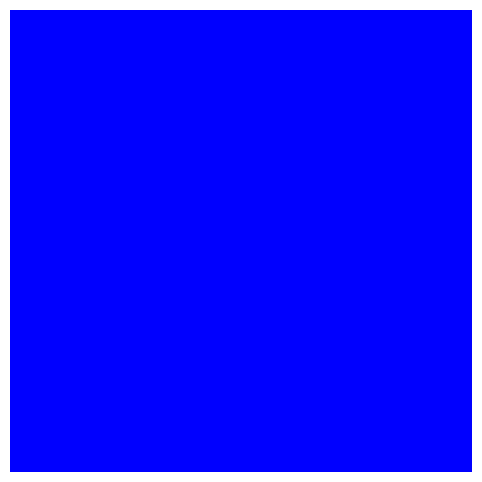

In [2]:
# 300x300x3(3채널 : B, G, R) 사이즈의 [255, 0, 0] 색상 이미지 생성
img = np.full((300, 300, 3), [255, 0, 0], dtype=np.uint8)

cv2_imshow(img)

# OpenCV 기본명령어 : 이미지

### 1. `cv2.imread('경로')`

In [3]:
img = cv2.imread(r'./imgs/opencv/imgs/astronaut.jpg')

`img` 변수에 `astronaut.jpg` 이미지의 넘파이 배열값을 저장하는 코드

### 2. `cv2.imshow('창 이름', 이미지 변수)`



In [4]:
if False :  # 이 명령어 셀을 실행하지 못하게 만들 목적으로 넣은 것이니, 무시해도 됨.

    cv2.imshow('window', img)

저장한 이미지 변수를 `'창 이름'` 창에 실제로 띄우게 하는 코드

다만 이 경우는 아주 잠깐 뜨다가 사라진다.

아래 코드로 무한 루프를 적용시켜 종료 키가 작동되기 전까지 뜨도록 만들어줘야 유지된다.

In [5]:
if False: # 이 명령어 셀을 실행하지 못하게 만들 목적으로 넣은 것이니, 무시해도 됨.

    cv2.waitKey(0)
    cv2.destroyAllWindows()

`cv2.waitKey(0)` 안 인자 `0`은

아무 키를 눌렀을 때 창을 종료시키겠다는 의미이고

`cv2.destroyAllWindows()`는

모든 열려있던 창을 종료시키겠다는 의미이다.

참고로 만약 이 코드를 `google Colab`에서 실행시키고 있다면

`cv2.imshow('창 이름', 이미지 변수)` 코드 실행 시 에러가 나는데

이는 `cv2.imshow`가 로컬 시스템에서 동작하는 방식인데, 

Colab의 경우 서버를 이용하는 방식을 사용하기 때문이다.

Colab에서 이를 쓰려면

```python
from google.colab.patches import cv2_imshow
```

의 `cv2_imshow(이미지 변수)`를 사용하면 에러 없이 이미지를 띄울 수 있다.

# OpenCV 기본명령어 : 영상

영상은 이미지의 연속이다.

즉 여러 장의 이미지를 몇 초의 아주 짧은 간격으로 띄울 것인가로 이해하면 된다.

OpenCV 영상 기본 코드 구조는 아래와 같다. (함수 안 코드)

In [6]:
def video(): # colab에서 이대로 실행하면 제대로 작동하지 않으므로 함수화 함. 내용만 보면 됨.
    import cv2
    cap = cv2.VideoCapture(r'./imgs/opencv/videos/turtle.mp4')

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        cv2.imshow('video', frame)
        
        if cv2.waitKey(10) == ord('q'):      # 대기시간(ms)
            break
        
        # waitkey = 1000/FPS : 1배속 설정

    cap.release()               # 비디오 장치 사용후 자원을 해제
    cv2.destroyAllWindows()     # 모든 opencv 창 닫기

### 1. `cv2.VideoCapture('경로')`

In [7]:
cap = cv2.VideoCapture(r'./imgs/opencv/videos/turtle.mp4')

영상을 받아올 통로 변수 `cap`를 생성하는 명령어이다.

추가로 동영상 데이터 뿐만 아니라 웹캠, 노트북의 카메라 영상 데이터도 가져올 수 있는데

`'경로'` 대신 숫자(0, 1, 2, ...)을 넣으면 된다.

연결된 카메라 순서대로 번호가 붙으며 보통 노트북의 내장 캠이 0번을 받지만 시스템에 따라 다를 수 있다.

### 2. `ret, frame = cap.read()`

In [8]:
ret, frame = cap.read()

연결된 통로로부터 이미지를 1장씩 받아오는 코드.

`ret`은 이미지를 제대로 받은 경우 True, 아닌경우 False값이 되며

`frame`이 받은 이미지의 numpy 배열값이 된다.

### 3. `cv2.waitKey(10) == ord('q')`

In [9]:
if False: # 이 명령어 셀을 실행하지 못하게 만들 목적으로 넣은 것이니, 무시해도 됨.
    while True : 
        if cv2.waitKey(10) == ord('q'):      # 대기시간(ms)
            break

`cv2.waitKey(0)` 는 아무 키나 누를 시 종료하겠다는 코드였다.

`cv2.waitKey(10)` 은 10ms, 즉 0.01초마다 입력키를 확인하겠다는 것이고

`ord(q)`는 `q`키의 번호이다.

즉 10ms(0.01초) 마다 눌러진 키가 `q`인가를 확인하는 코드이자,

while문을 10ms마다 순환하겠다는 코드이므로

영상을 0.01초마다 띄우겠다는 코드이다.

뒤 코드를 보면 알겠지만 `cv2.waitKey(10) == ord('q')` 이면 `break`로 탈출하는데

이는 `q`를 누른 것이 확인되면 영상 송출을 멈추겠다는 코드이다.



### 4. `cap.release()`

`cap`연결을 해제하겠다는 코드이다.

# OpenCV 이미지 조작 기본 명령어

### 원본 이미지

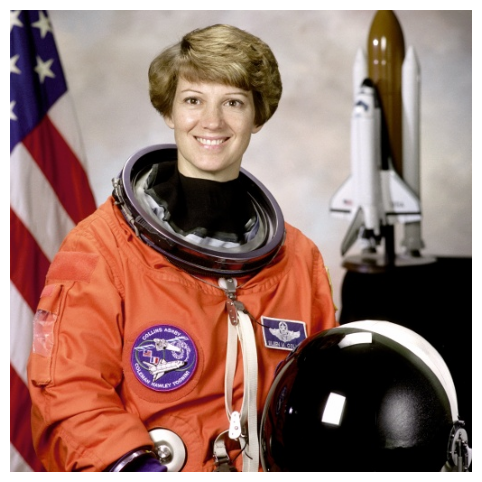

In [10]:
cv2_imshow(img)

### 0. 이미지 복제

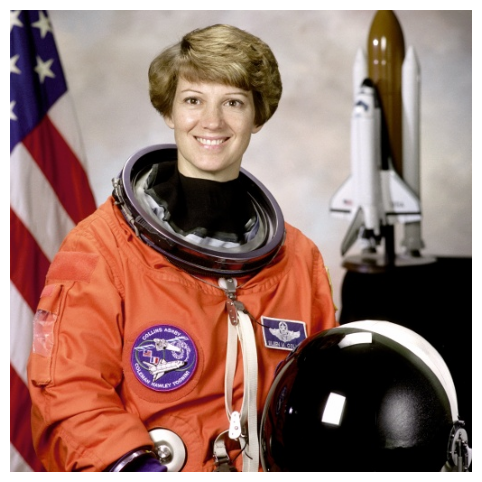

In [24]:
img_copy = img.copy()

cv2_imshow(img_copy)

### 1. 색 순서 전환

### (1) BGR $\rightarrow$ RGB

`cv2.COLOR_BGR2RGB`

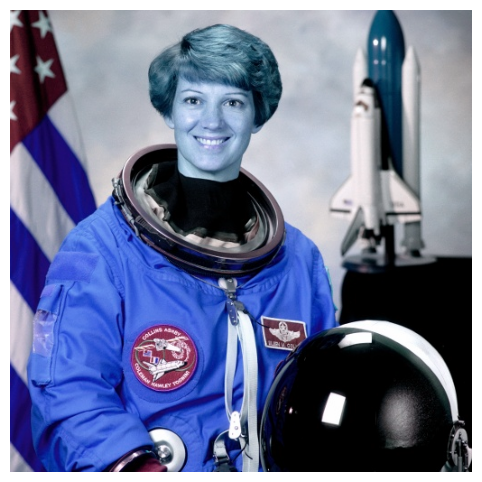

In [11]:
# 색 변환 코드 1줄
img_rev = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 창에 띄우는 코드
cv2_imshow(img_rev) # 로컬은 cv2.imshow('img', img)

### (2) 흑백변환

`cv2.COLOR_BGR2GRAY`

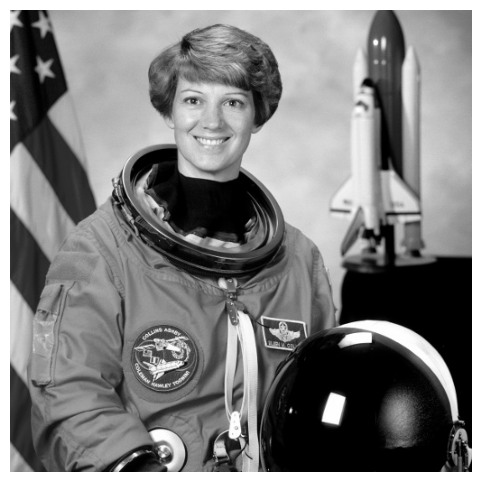

In [12]:
# 색 변환 코드 1줄
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 창에 띄우는 코드
cv2_imshow(img_gray) # 로컬은 cv2.imshow('img', img)

### 2. 밝기 조절

### (1) `cv2.add()`

명도 증가 (HSV에서 V 증가)

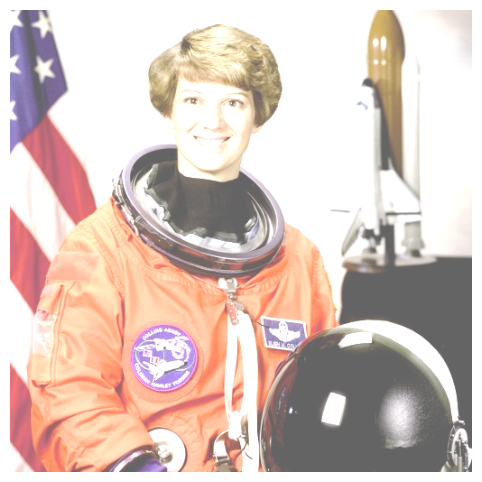

In [13]:
img_bright = cv2.add(img, 100)

cv2_imshow(img_bright)

### (2) `cv2.subtract()`

명도 감소 (HSV에서 V 감소)

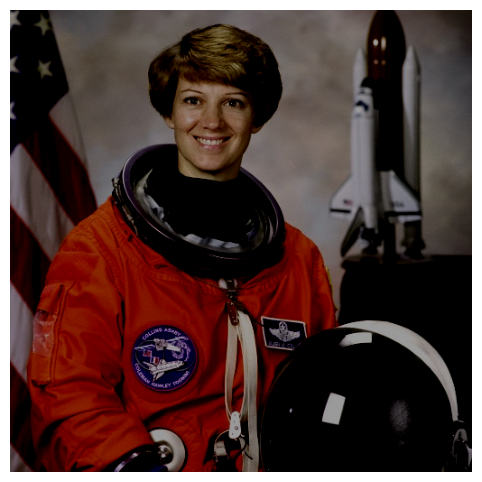

In [14]:
img_dark = cv2.subtract(img, 100)

cv2_imshow(img_dark)

### (3) Multiply, divide

이미지 배열값들을 곱 또는 나누기화

255를 넘어갈 경우 자동으로 255 처리



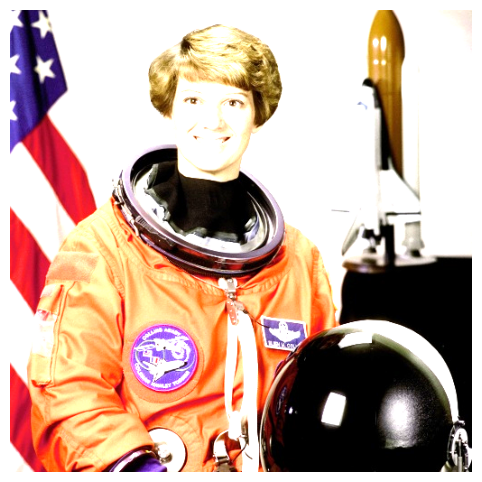

In [15]:
img_multiply = cv2.multiply(img, 2)
cv2_imshow(img_multiply)

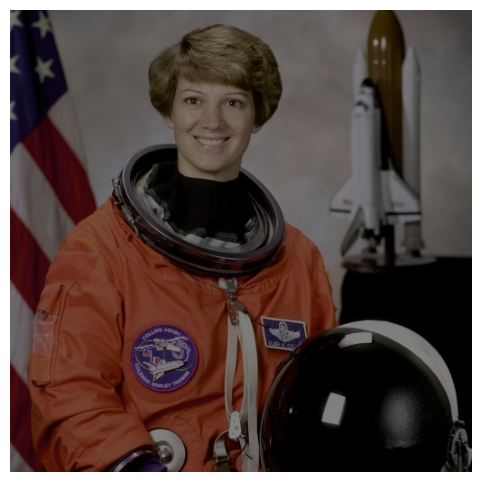

In [16]:
img_divide = cv2.divide(img, 2)
cv2_imshow(img_divide)

### 3. 기본 도형 만들기

주의사항 : 

np배열을 이용해 이미지를 만들 경우

데이터타입을 정수형(`np.uint`)로 설정해줘야 오류가 발생하지 않는다.

실수형(`np.float64`(default)) 등 다른 데이터타입인 경우 에러가 발생한다.

### (1) 배경이 될 도화지 만들기

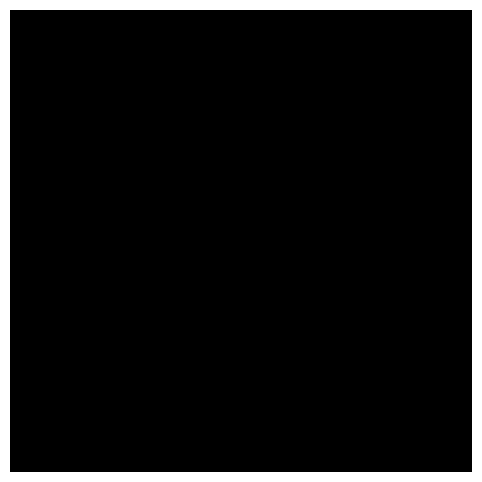

In [53]:
bg = np.zeros((200, 200, 3), dtype=np.uint8) # dtype=np.uint8 

cv2_imshow(bg)

np배열 이미지 복제

In [79]:
bg_rec1 = bg.copy()
bg_rec2 = bg.copy()
bg_cir1 = bg.copy()
bg_cir2 = bg.copy()
bg_line = bg.copy()
bg_poly1 = bg.copy()
bg_poly2 = bg.copy()
bg_text = bg.copy()

### (2) 배경 위 도형 그리기

I. 직사각형

```python
cv2.rectangle(배경변수, 시작점(왼쪽 위), 끝점(오른쪽 아래), 색상(BGR), 선 두께)
```

선 두께에 -1을 넣으면 내부를 채워준다.

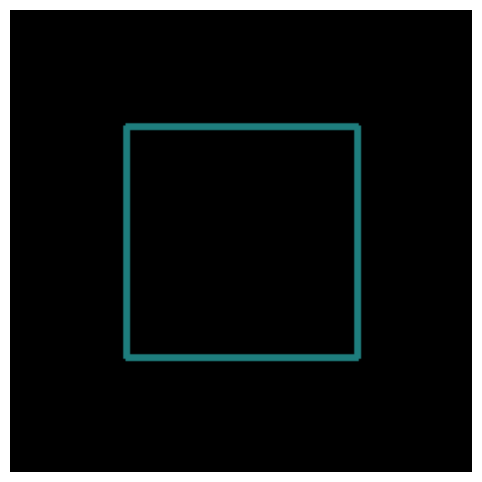

In [42]:
cv2.rectangle(bg_rec1, (50,50), (150,150), (125,125,30), 2)

cv2_imshow(bg_rec1)

내부 채우기(-1)

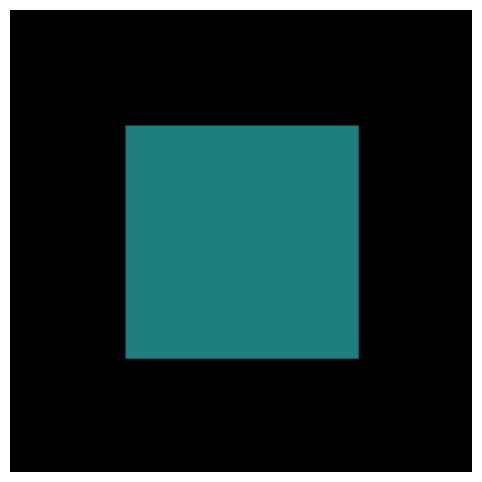

In [43]:
cv2.rectangle(bg_rec2, (50,50), (150,150), (125,125,30), -1)

cv2_imshow(bg_rec2)

II. 원그리기

```python
cv2.circle(배경변수, 중심점, 반지름, 색상(BGR), 선 두께)
```

마찬가지로 선 두께 대신 -1을 넣으면 내부를 채워준다.

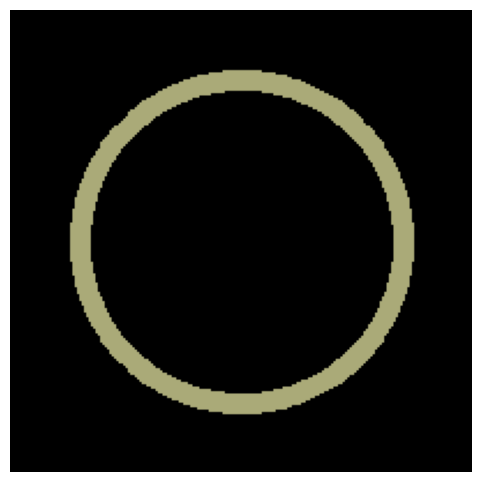

In [45]:
cv2.circle(bg_cir1, (100,100), 70, (120, 170, 170), 8)

cv2_imshow(bg_cir1)

내부채우기(-1)

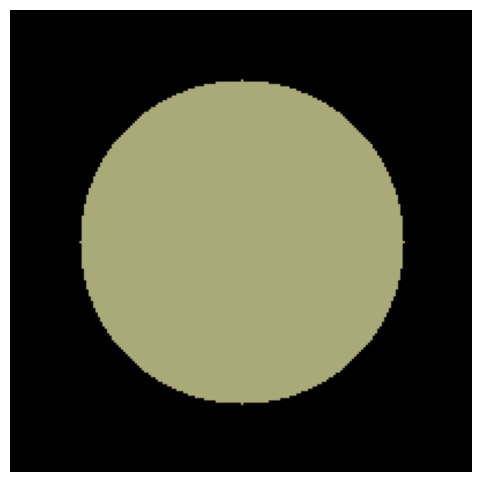

In [44]:
cv2.circle(bg_cir2, (100,100), 70, (120, 170, 170), -1)

cv2_imshow(bg_cir2)

III. 직선

`cv2.line(배경변수, 시작점, 끝점, 색상, 두께)`

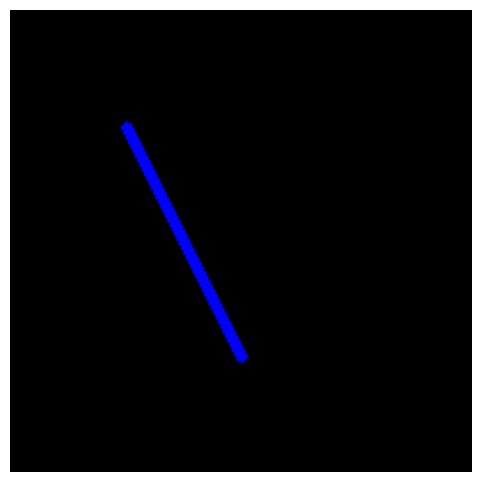

In [60]:
cv2.line(bg_line, (50, 50), (100, 150), (255, 0, 0), 3)

cv2_imshow(bg_line)

IV. 다각형 그리기

(a) 테두리만 그리기

```python
cv2.polylines(이미지, [꼭지점들 좌표배열], 닫힘여부, 색상, 두께)
```

데이터타입은 `int32`를 꼭 써야 한다. `uint8`또는 `uint16` 같은 다른 데이터타입을 사용하면 에러발생.


꼭지점 설정

In [57]:
pts = np.array([[100, 50], [150, 150], [50, 150]], np.int32)

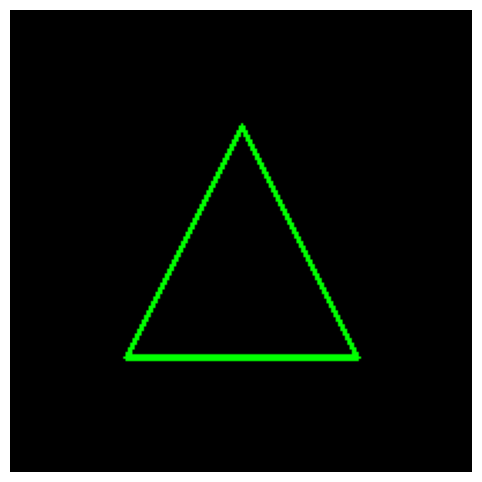

In [62]:
cv2.polylines(bg_poly1, [pts], isClosed=True, color=(0, 255, 0), thickness=2)

cv2_imshow(bg_poly1)

(b) 내부 채우기

```python
cv2.fillPoly(배경변수, [꼭지점들 좌표배열], 색상)
```

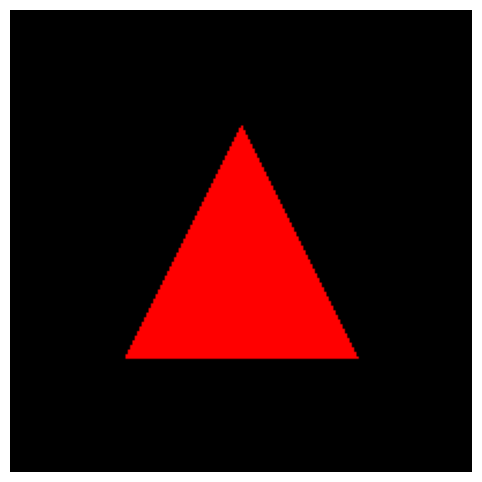

In [63]:
cv2.fillPoly(bg_poly2, [pts], (0, 0, 255))

cv2_imshow(bg_poly2)

V. 텍스트

```python
cv2.putText(배경변수, 텍스트, 위치, 폰트, 크기, 색상, 두께)
```

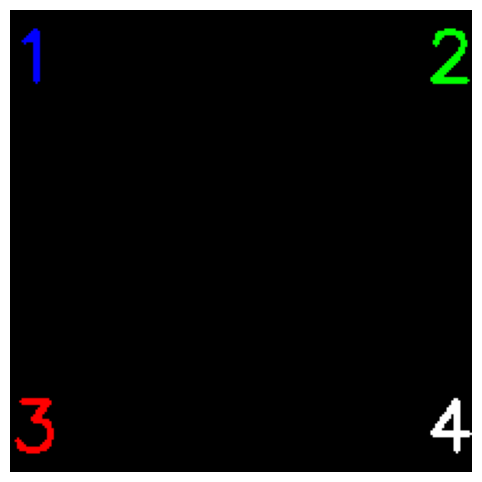

In [80]:
cv2.putText(bg_text, "1", (0, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
cv2.putText(bg_text, "2", (180, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
cv2.putText(bg_text, "3", (0, 190), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
cv2.putText(bg_text, "4", (180, 190), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

cv2_imshow(bg_text)

## 논리 연산


#### AND, OR, XOR

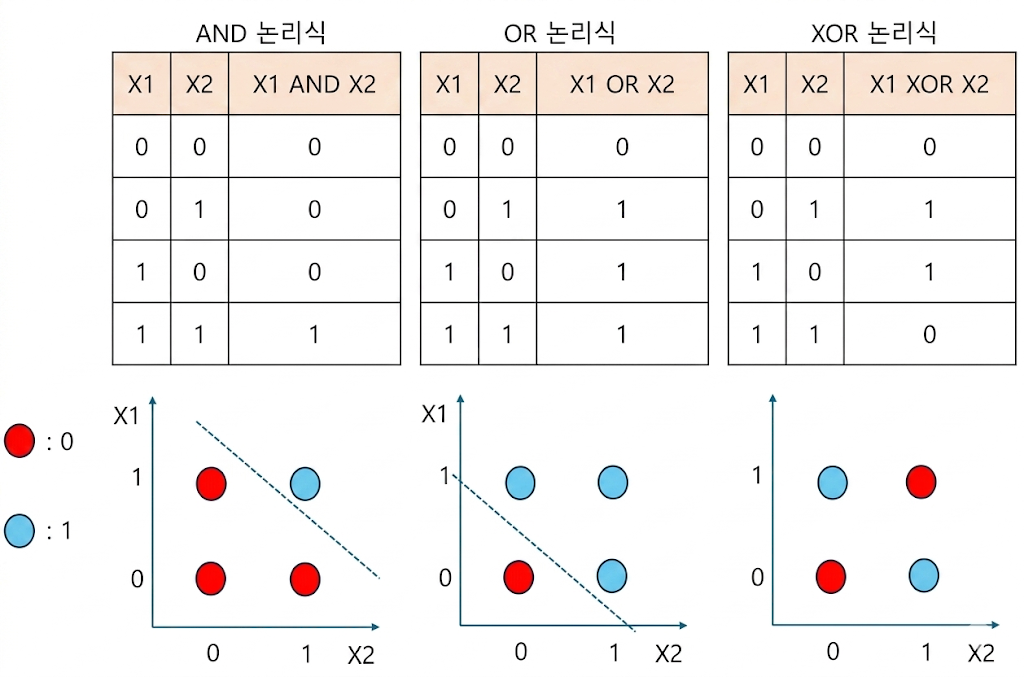

In [83]:
a, b = 154, 205
print(f"{a} and {b} = {a & b}")
print(f"{a} or {b} = {a | b}")
print(f"{a} xor {b} = {a ^ b}")

154 and 205 = 136
154 or 205 = 223
154 xor 205 = 87


`AND` 연산

$$
\begin{aligned}
  &10011010_{(2)} = 154\\
  &11001101_{(2)} = 205\\
  \hline
  &10001000_{(2)} = 136
\end{aligned}
$$

`OR` 연산

$$
\begin{aligned}
  &10011010_{(2)} = 154\\
  &11001101_{(2)} = 205\\
  \hline
  &11011111_{(2)} = 223
\end{aligned}
$$

`XOR` 연산

$$
\begin{aligned}
  &10011010_{(2)} = 154\\
  &11001101_{(2)} = 205\\
  \hline
  &01010111_{(2)} = 87
\end{aligned}
$$

#### NOT

1 $\rightarrow$ 0, 0 $\rightarrow$ 1

In [85]:
print(f"not {a} : {255-a}, not {b} : {255-b}")

not 154 : 101, not 205 : 50


$154 = 10011010_{(2)} \rightarrow 01100101_{(2)} = 101$

$205 = 11001101_{(2)} \rightarrow 00110010_{(2)} = 50$

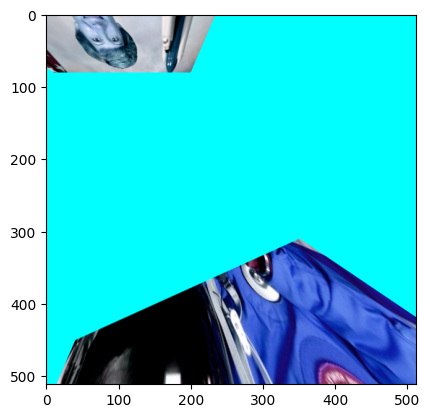

In [17]:
import cv2, numpy as np, matplotlib.pyplot as plt
image_path = './imgs/opencv/imgs/astronaut.jpg'

src = cv2.imread(image_path)
height, width, _ = src.shape

src_pts = np.array([[0.0, 0.0], [width, 0.0], [width, height], [0.0, height]], dtype=np.float32)
dst_pts = np.array([[10, 80], [200, 80], [40, 450], [350,310]], dtype=np.float32)

# 변환 행렬 계산
# 원본 4 포인트(어디서 출발?) >> 목표 4 포인트(어디로 가지?)
M = cv2.getPerspectiveTransform(src_pts, dst_pts)

# 원근 변환 적용
# cv2.warpPerspective(src, M, (widht, height))
dst = cv2.warpPerspective(src, M, (width, height), borderValue=(0,255,255))
# src: 원본 이미지, M: 변환 행렬, 원하는 출력 크기(width, height), borderVale(BGR) 빈공간 색상

plt.imshow(dst)
# borderValue=(0,255,255)  원래 openCV는 BGR 여야 해서 yellow 가 나와야 함
# 그런데 우리가 matplotlib 사용하다 보니 RGB로 나와서 cyan(청록색) 거예요